In [28]:
import config
config.configure_global_paths()
from model.ts2vec.ts2vec import TS2Vec_Learner
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from utils.utils import create_windows, normalise, score_windows
from model.ts2vec.utils import create_ts2vec_dataset
import matplotlib.pyplot as plt
from utils.metrics import all_metrics

In [2]:
model = TS2Vec_Learner(
        input_dims=1,
        output_dims=12,
        train_data = np.random.randn(1,1,1),
        device="cpu",
    )
model.net.load_state_dict(torch.load('/home/onyxia/work/moving_mahalanobis/model/ts2vec/model_weights.pth',
                                     map_location=torch.device('cpu')))

/tmp/ipykernel_233819/3377116783.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.net.load_state_dict(torch.load('/home/onyxia/work/moving_mahalanobis/model/ts2vec/

<All keys matched successfully>

In [10]:
import pandas as pd
seq_len = 32
path_to_file = "/home/onyxia/work/moving_mahalanobis/data/NAB_anomaly/ec2_cpu_utilization_ac20cd.csv"
df = pd.read_csv(path_to_file)
X = df["value"].to_numpy()
y = df["label"].to_numpy()
y = create_windows(y.flatten(), seq_len=seq_len, stride=seq_len)
loader = create_ts2vec_dataset(X, model, seq_len=seq_len, stride=seq_len, device="cpu")

In [9]:
from model.M_mahala.movingmahala import MovingMahalanobis

In [12]:
mahala = MovingMahalanobis(y, loader, model_name="TS2Vec", X=X, seq_len=32)
out = mahala.fit(print_results=False, thresh=12, mode_auto=True, windows=True,
                 verbose=True, n_channels = 12)
for key in out.keys():
    print(key, ":", out[key])

100%|██████████| 125/125 [00:03<00:00, 31.76it/s]


Accuracy : 0.9911504424778761
F1 : 0.6666666666666666
Precision : 0.5
Recall : 1.0
Roc_Auc : 0.9910714285714286
AUPr : 0.5
FPR@95% : 0.008928571428571428
n_anomaly : 1
n_data : 113
model : TS2Vec


In [21]:
mahala.score.max()

6956.616808585548

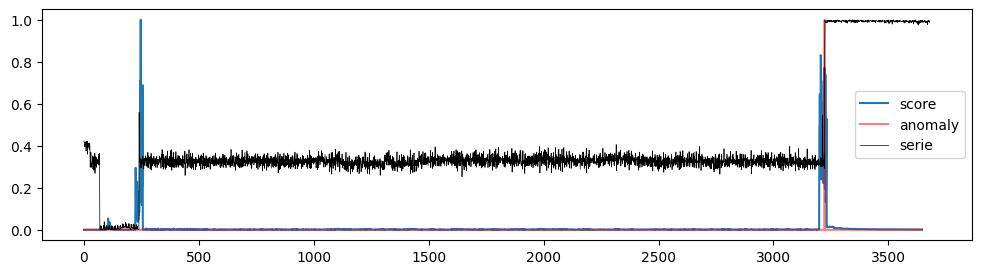

In [25]:
plt.figure(figsize=(12,3))
plt.plot(normalise(np.clip(mahala.score, None, 7000)), label="score")
plt.plot(mahala.labels, alpha=0.5, c="r", label="anomaly")
plt.plot(normalise(mahala.X.flatten()), linewidth=0.5, alpha=1, c="black", label="serie")
plt.legend()
plt.show()

Accuracy: 0.9912
F1 Score: 0.6667
Precision: 0.5000
Recall: 1.0000
AUC: 0.9911
AUPR: 0.5000
Taux de faux positifs à 95% de sensibilité : 0.0089


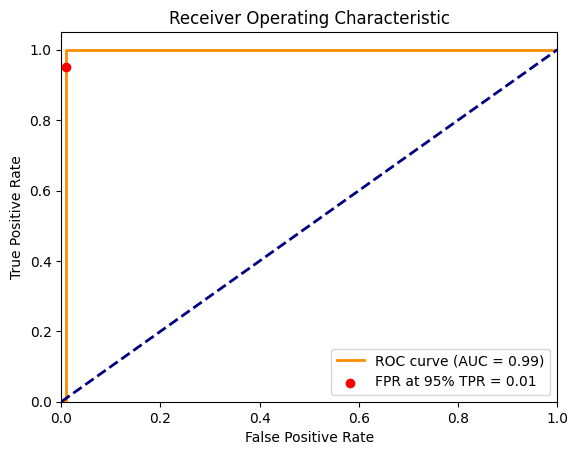

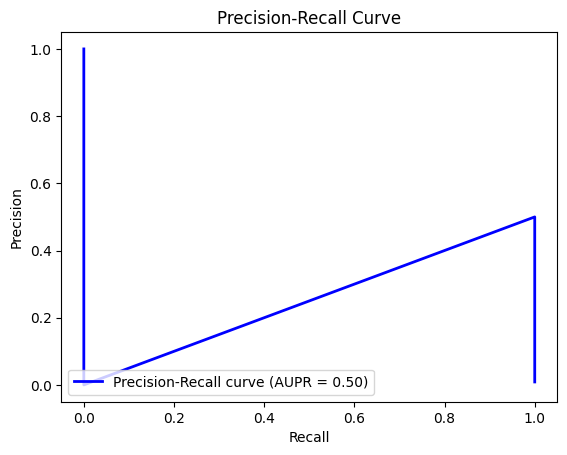

{'Accuracy': 0.9911504424778761,
 'F1': 0.6666666666666666,
 'Precision': 0.5,
 'Recall': 1.0,
 'Roc_Auc': 0.9910714285714286,
 'AUPr': 0.5,
 'FPR@95%': 0.008928571428571428,
 'n_anomaly': 1,
 'n_data': 113,
 'model': '...'}

In [29]:
label_w, score_w = score_windows(mahala.labels, mahala.score, seq_len=32)
all_metrics(label_w, score_w, verbose=True)